In [ ]:
# Create Project Directory in Google Drive

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/SupportPilotAI"

folders = [
    "datasets/raw",
    "datasets/processed",
    "datasets/mappings",
    "notebooks",
    "models",
    "outputs",
    "reports",
    "knowledge_base",
    "src",
    "evaluation",
    "docs"
]

os.makedirs(PROJECT_ROOT, exist_ok=True)

for folder in folders:
    os.makedirs(os.path.join(PROJECT_ROOT, folder), exist_ok=True)

print("Project directory created successfully!\n")

for folder in folders:
    print(os.path.join(PROJECT_ROOT, folder))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory created successfully!

/content/drive/MyDrive/SupportPilotAI/datasets/raw
/content/drive/MyDrive/SupportPilotAI/datasets/processed
/content/drive/MyDrive/SupportPilotAI/datasets/mappings
/content/drive/MyDrive/SupportPilotAI/notebooks
/content/drive/MyDrive/SupportPilotAI/models
/content/drive/MyDrive/SupportPilotAI/outputs
/content/drive/MyDrive/SupportPilotAI/reports
/content/drive/MyDrive/SupportPilotAI/knowledge_base
/content/drive/MyDrive/SupportPilotAI/src
/content/drive/MyDrive/SupportPilotAI/evaluation
/content/drive/MyDrive/SupportPilotAI/docs


In [ ]:
# Project Configuration

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/SupportPilotAI")

RAW_DATA_DIR = PROJECT_ROOT / "datasets" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "datasets" / "processed"
MAPPINGS_DIR = PROJECT_ROOT / "datasets" / "mappings"

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
KNOWLEDGE_BASE_DIR = PROJECT_ROOT / "knowledge_base"

print("=" * 60)
print("SupportPilot AI - Project Configuration")
print("=" * 60)

print(f"Project Root      : {PROJECT_ROOT}")
print(f"Raw Data          : {RAW_DATA_DIR}")
print(f"Processed Data    : {PROCESSED_DATA_DIR}")
print(f"Mappings          : {MAPPINGS_DIR}")
print(f"Models            : {MODELS_DIR}")
print(f"Reports           : {REPORTS_DIR}")
print(f"Outputs           : {OUTPUTS_DIR}")
print(f"Knowledge Base    : {KNOWLEDGE_BASE_DIR}")

SupportPilot AI - Project Configuration
Project Root      : /content/drive/MyDrive/SupportPilotAI
Raw Data          : /content/drive/MyDrive/SupportPilotAI/datasets/raw
Processed Data    : /content/drive/MyDrive/SupportPilotAI/datasets/processed
Mappings          : /content/drive/MyDrive/SupportPilotAI/datasets/mappings
Models            : /content/drive/MyDrive/SupportPilotAI/models
Reports           : /content/drive/MyDrive/SupportPilotAI/reports
Outputs           : /content/drive/MyDrive/SupportPilotAI/outputs
Knowledge Base    : /content/drive/MyDrive/SupportPilotAI/knowledge_base


In [ ]:
from pathlib import Path

print("=" * 70)
print("SupportPilot AI - Dataset Verification")
print("=" * 70)

for folder in sorted(RAW_DATA_DIR.iterdir()):
    if folder.is_dir():
        print(f"\n📁 {folder.name}")

        files = list(folder.iterdir())

        if len(files) == 0:
            print("   No files found.")
        else:
            for file in sorted(files):
                size_mb = file.stat().st_size / (1024 * 1024)
                print(f"   📄 {file.name} ({size_mb:.2f} MB)")

SupportPilot AI - Dataset Verification

📁 banking77
   📄 categories.json (0.00 MB)
   📄 test.csv (0.23 MB)
   📄 train.csv (0.80 MB)

📁 bitext
   📄 Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv (18.31 MB)

📁 sentiment140
   📄 training.1600000.processed.noemoticon.csv (227.74 MB)


In [ ]:
# Load All Datasets


# ==============================
# Import Required Libraries
# ==============================

import pandas as pd

# ==============================
# Define Dataset Paths
# ==============================

bitext_path = RAW_DATA_DIR / "bitext" / "Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv"

banking_train_path = RAW_DATA_DIR / "banking77" / "train.csv"
banking_test_path = RAW_DATA_DIR / "banking77" / "test.csv"

sentiment_path = RAW_DATA_DIR / "sentiment140" / "training.1600000.processed.noemoticon.csv"

# ==============================
# Load Bitext Dataset
# ==============================

bitext_df = pd.read_csv(bitext_path)

# ==============================
# Load Banking77 Dataset
# ==============================

banking_train_df = pd.read_csv(banking_train_path)

banking_test_df = pd.read_csv(banking_test_path)

# ==============================
# Load Sentiment140 Dataset
# ==============================

sentiment_df = pd.read_csv(
    sentiment_path,
    encoding="latin-1",
    header=None
)

# ==============================
# Display Dataset Shapes
# ==============================

print("=" * 60)
print("Datasets Loaded Successfully")
print("=" * 60)

print(f"Bitext Dataset Shape          : {bitext_df.shape}")

print(f"Banking77 Train Shape         : {banking_train_df.shape}")

print(f"Banking77 Test Shape          : {banking_test_df.shape}")

print(f"Sentiment140 Shape            : {sentiment_df.shape}")

Datasets Loaded Successfully
Bitext Dataset Shape          : (26872, 5)
Banking77 Train Shape         : (10003, 2)
Banking77 Test Shape          : (3080, 2)
Sentiment140 Shape            : (1600000, 6)


In [ ]:
# Dataset Schema Analysis

# ============================================
# Function to Analyze Dataset Schema
# ============================================

def analyze_dataset(df, dataset_name):

    print("\n" + "=" * 80)
    print(f"{dataset_name}")
    print("=" * 80)

    # Shape
    print(f"\nShape: {df.shape}")

    # Column names
    print("\nColumns:")
    print(df.columns.tolist())

    # Data types
    print("\nData Types:")
    print(df.dtypes)

    # Missing values
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Sample records
    print("\nFirst 5 Rows:")
    display(df.head())


# ============================================
# Analyze All Datasets
# ============================================

analyze_dataset(bitext_df, "Bitext Customer Support Dataset")

analyze_dataset(banking_train_df, "Banking77 Train Dataset")

analyze_dataset(banking_test_df, "Banking77 Test Dataset")

analyze_dataset(sentiment_df, "Sentiment140 Dataset")


Bitext Customer Support Dataset

Shape: (26872, 5)

Columns:
['flags', 'instruction', 'category', 'intent', 'response']

Data Types:
flags          object
instruction    object
category       object
intent         object
response       object
dtype: object

Missing Values:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

First 5 Rows:


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...



Banking77 Train Dataset

Shape: (10003, 2)

Columns:
['text', 'category']

Data Types:
text        object
category    object
dtype: object

Missing Values:
text        0
category    0
dtype: int64

First 5 Rows:


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival



Banking77 Test Dataset

Shape: (3080, 2)

Columns:
['text', 'category']

Data Types:
text        object
category    object
dtype: object

Missing Values:
text        0
category    0
dtype: int64

First 5 Rows:


,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival



Sentiment140 Dataset

Shape: (1600000, 6)

Columns:
[0, 1, 2, 3, 4, 5]

Data Types:
0     int64
1     int64
2    object
3    object
4    object
5    object
dtype: object

Missing Values:
0    0
1    0
2    0
3    0
4    0
5    0
dtype: int64

First 5 Rows:


,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
# Target Variable Analysis

# ============================================
# Analyze Target Variables
# ============================================

print("=" * 80)
print("Bitext Dataset")
print("=" * 80)

print(f"\nTotal Business Categories : {bitext_df['category'].nunique()}")
print(f"Total Intent Classes      : {bitext_df['intent'].nunique()}")

print("\nTop 10 Business Categories")
display(bitext_df["category"].value_counts().head(10))

print("\nTop 10 Intent Classes")
display(bitext_df["intent"].value_counts().head(10))


print("\n" + "=" * 80)
print("Banking77 Dataset")
print("=" * 80)

print(f"\nTotal Intent Classes : {banking_train_df['category'].nunique()}")

print("\nTop 10 Intent Classes")
display(banking_train_df["category"].value_counts().head(10))

Bitext Dataset

Total Business Categories : 11
Total Intent Classes      : 27

Top 10 Business Categories


,count
category,
ACCOUNT,5986
ORDER,3988
REFUND,2992
CONTACT,1999
INVOICE,1999
PAYMENT,1998
FEEDBACK,1997
DELIVERY,1994
SHIPPING,1970



Top 10 Intent Classes


,count
intent,
contact_customer_service,1000
complaint,1000
check_invoice,1000
switch_account,1000
edit_account,1000
contact_human_agent,999
check_payment_methods,999
delivery_period,999
newsletter_subscription,999



Banking77 Dataset

Total Intent Classes : 77

Top 10 Intent Classes


,count
category,
card_payment_fee_charged,187
direct_debit_payment_not_recognised,182
balance_not_updated_after_cheque_or_cash_deposit,181
wrong_amount_of_cash_received,180
cash_withdrawal_charge,177
transaction_charged_twice,175
declined_cash_withdrawal,173
transfer_fee_charged,172
balance_not_updated_after_bank_transfer,171


In [ ]:
# Dataset Quality & Distribution Analysis

# ============================================
# Analyze Bitext Dataset Quality
# ============================================

# Total records
print("=" * 80)
print("Bitext Dataset Quality Report")
print("=" * 80)

print(f"\nTotal Records               : {len(bitext_df)}")

# Duplicate analysis
duplicate_queries = bitext_df["instruction"].duplicated().sum()
duplicate_responses = bitext_df["response"].duplicated().sum()

print(f"Duplicate Queries           : {duplicate_queries}")
print(f"Duplicate Responses         : {duplicate_responses}")

# Query length
bitext_df["query_length"] = bitext_df["instruction"].str.split().str.len()

# Response length
bitext_df["response_length"] = bitext_df["response"].str.split().str.len()

print("\nQuery Length Statistics")
display(bitext_df["query_length"].describe())

print("\nResponse Length Statistics")
display(bitext_df["response_length"].describe())

print("\nTop 10 Business Categories")
display(bitext_df["category"].value_counts().head(10))

print("\nTop 10 Intent Classes")
display(bitext_df["intent"].value_counts().head(10))

Bitext Dataset Quality Report

Total Records               : 26872
Duplicate Queries           : 2237
Duplicate Responses         : 2

Query Length Statistics


,query_length
count,26872.000000
mean,8.690979
std,2.605004
min,1.000000
25%,7.000000
50%,9.000000
75%,11.000000
max,16.000000



Response Length Statistics


,response_length
count,26872.000000
mean,104.789037
std,52.966204
min,9.000000
25%,72.000000
50%,90.000000
75%,124.000000
max,402.000000



Top 10 Business Categories


,count
category,
ACCOUNT,5986
ORDER,3988
REFUND,2992
CONTACT,1999
INVOICE,1999
PAYMENT,1998
FEEDBACK,1997
DELIVERY,1994
SHIPPING,1970



Top 10 Intent Classes


,count
intent,
contact_customer_service,1000
complaint,1000
check_invoice,1000
switch_account,1000
edit_account,1000
contact_human_agent,999
check_payment_methods,999
delivery_period,999
newsletter_subscription,999


In [ ]:
# Dataset Mapping Summary

# ============================================
# Create Dataset Mapping Document
# ============================================

import pandas as pd

# Create dataset mapping
dataset_mapping = pd.DataFrame({
    "Dataset": [
        "Bitext Customer Support",
        "Banking77",
        "Sentiment140"
    ],
    "Purpose": [
        "Intent Classification, Response Generation",
        "External Validation of Intent Model",
        "Sentiment Analysis"
    ],
    "Input Column": [
        "instruction",
        "text",
        "5 (tweet)"
    ],
    "Target Column": [
        "intent",
        "category",
        "0 (sentiment)"
    ],
    "Project Module": [
        "Intent Classification + LLM",
        "Model Evaluation",
        "Sentiment Analysis"
    ],
    "Status": [
        "Primary Dataset",
        "External Dataset",
        "Primary Dataset"
    ]
})

# Display mapping
print("=" * 80)
print("SupportPilot AI - Dataset Mapping")
print("=" * 80)

display(dataset_mapping)

# Save mapping
mapping_file = MAPPINGS_DIR / "dataset_mapping.csv"
dataset_mapping.to_csv(mapping_file, index=False)

print(f"\nDataset mapping saved to:\n{mapping_file}")

SupportPilot AI - Dataset Mapping


,Dataset,Purpose,Input Column,Target Column,Project Module,Status
0,Bitext Customer Support,"Intent Classification, Response Generation",instruction,intent,Intent Classification + LLM,Primary Dataset
1,Banking77,External Validation of Intent Model,text,category,Model Evaluation,External Dataset
2,Sentiment140,Sentiment Analysis,5 (tweet),0 (sentiment),Sentiment Analysis,Primary Dataset



Dataset mapping saved to:
/content/drive/MyDrive/SupportPilotAI/datasets/mappings/dataset_mapping.csv


In [ ]:
# ============================================
# Raw Text Inspection - Bitext Dataset
# ============================================

import re

print("=" * 80)
print("RAW TEXT INSPECTION")
print("=" * 80)

# Display random customer queries
print("\nSample Customer Queries:\n")
display(bitext_df["instruction"].sample(10, random_state=42))

# Display random AI responses
print("\nSample AI Responses:\n")
display(bitext_df["response"].sample(10, random_state=42))

# Detect placeholders like {{Order Number}}
placeholder_count = bitext_df["instruction"].str.contains(
    r"\{\{.*?\}\}", regex=True
).sum()

# Detect URLs
url_count = bitext_df["instruction"].str.contains(
    r"http[s]?://|www\.",
    regex=True,
    case=False
).sum()

# Detect HTML tags
html_count = bitext_df["instruction"].str.contains(
    r"<.*?>",
    regex=True
).sum()

# Detect email addresses
email_count = bitext_df["instruction"].str.contains(
    r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}",
    regex=True
).sum()

print("\n" + "=" * 80)
print("Noise Analysis")
print("=" * 80)

print(f"Queries containing placeholders : {placeholder_count}")
print(f"Queries containing URLs         : {url_count}")
print(f"Queries containing HTML tags    : {html_count}")
print(f"Queries containing Email IDs    : {email_count}")

RAW TEXT INSPECTION

Sample Customer Queries:



,instruction
9329,I can't talk with a human agent
4160,I have got to locate hte bills from {{Person N...
18500,"I cannot pay, help me to inform of a problem w..."
8840,I want help speaking to customer service
5098,I try to see th accepted payment options
17250,where to sign up to the company nmewsletter
3589,I'd like to see the withdrwaal fee how can i d...
9043,I want to speak with someone
15800,can you help me getting bill #85632?
4384,I don't know how to take a quick look at invoi...



Sample AI Responses:



,response
9329,Thank you for reaching out! I'm sorry to hear ...
4160,I'll get right on it! I understand your need t...
18500,I apologize for the inconvenience caused by th...
8840,Grateful for your contact! I get the sense tha...
5098,Thank you for reaching out! I completely under...
17250,Thank you for your interest in signing up for ...
3589,"I'll do my best! To view the withdrawal fee, y..."
9043,I see what you mean! I'm on the same page that...
15800,I'll take care of it! I completely understand ...
4384,I've realized you're unsure about how to quick...



Noise Analysis
Queries containing placeholders : 6670
Queries containing URLs         : 0
Queries containing HTML tags    : 0
Queries containing Email IDs    : 0


In [ ]:
# ============================================
# Duplicate Query Investigation
# ============================================

print("=" * 80)
print("Duplicate Query Investigation")
print("=" * 80)

# Count occurrences of each query
duplicate_counts = (
    bitext_df["instruction"]
    .value_counts()
)

# Keep only queries occurring more than once
duplicate_queries = duplicate_counts[duplicate_counts > 1]

print(f"\nTotal Unique Duplicate Queries : {len(duplicate_queries)}")

print("\nTop 15 Most Frequent Duplicate Queries\n")

display(
    duplicate_queries.head(15)
)

# Show a few duplicate examples with their intent and response
print("\nSample Duplicate Records\n")

sample_duplicates = bitext_df[
    bitext_df["instruction"].isin(duplicate_queries.head(5).index)
].sort_values("instruction")

display(
    sample_duplicates[
        ["instruction", "category", "intent", "response"]
    ]
)

Duplicate Query Investigation

Total Unique Duplicate Queries : 989

Top 15 Most Frequent Duplicate Queries



,count
instruction,
shipments to {{Delivery City}},8
shiping to {{Delivery City}},8
do you deliver to {{Delivery City}}?,8
is it possible to order from {{Delivery City}},8
do ya deliver to {{Delivery City}},8
is it possible to order from {{Delivery City}}?,8
is it possible toorder from {{Delivery City}},8
deliveries to {{Delivery City}},8
can I place an order from {{Delivery City}}?,8



Sample Duplicate Records



,instruction,category,intent,response
12335,do ya deliver to {{Delivery City}},DELIVERY,delivery_options,Indeed! We are delighted to deliver to {{Deliv...
12684,do ya deliver to {{Delivery City}},DELIVERY,delivery_options,Greetings! It's fantastic to see your interest...
12625,do ya deliver to {{Delivery City}},DELIVERY,delivery_options,Positively! We are delighted to offer delivery...
12020,do ya deliver to {{Delivery City}},DELIVERY,delivery_options,"Ah, {{Delivery City}}, a city full of charm an..."
12561,do ya deliver to {{Delivery City}},DELIVERY,delivery_options,I'll make it happen! We take pride in deliveri...
12809,do ya deliver to {{Delivery City}},DELIVERY,delivery_options,Positively! Our delivery services extend to va...
12111,do ya deliver to {{Delivery City}},DELIVERY,delivery_options,"Ah, the beautiful city of {{Delivery City}}! O..."
12147,do ya deliver to {{Delivery City}},DELIVERY,delivery_options,Assuredly! I'm thrilled to inform you that we ...
12661,do you deliver to {{Delivery City}}?,DELIVERY,delivery_options,Definitely! We extend our delivery services to...
12338,do you deliver to {{Delivery City}}?,DELIVERY,delivery_options,Unquestionably! We extend our delivery service...


In [ ]:
# ============================================
# Schema Standardization
# ============================================

# Create copies to preserve raw datasets
bitext_std = bitext_df.copy()
banking_std = banking_train_df.copy()
sentiment_std = sentiment_df.copy()

# --------------------------------------------
# Standardize Banking77
# --------------------------------------------
banking_std.rename(
    columns={
        "text": "instruction",
        "category": "intent"
    },
    inplace=True
)

# --------------------------------------------
# Standardize Sentiment140
# --------------------------------------------
sentiment_std.columns = [
    "sentiment",
    "tweet_id",
    "date",
    "query",
    "username",
    "instruction"
]

# --------------------------------------------
# Display standardized schemas
# --------------------------------------------

print("=" * 80)
print("Standardized Dataset Schemas")
print("=" * 80)

print("\nBitext Columns")
print(bitext_std.columns.tolist())

print("\nBanking77 Columns")
print(banking_std.columns.tolist())

print("\nSentiment140 Columns")
print(sentiment_std.columns.tolist())

Standardized Dataset Schemas

Bitext Columns
['flags', 'instruction', 'category', 'intent', 'response', 'query_length', 'response_length']

Banking77 Columns
['instruction', 'intent']

Sentiment140 Columns
['sentiment', 'tweet_id', 'date', 'query', 'username', 'instruction']


In [ ]:
# ============================================
# Module-wise Dataset Creation
# ============================================

# --------------------------------------------
# Intent Classification + LLM Dataset
# --------------------------------------------
intent_df = bitext_std[
    ["instruction", "intent", "response"]
].copy()

# --------------------------------------------
# Banking Evaluation Dataset
# --------------------------------------------
banking_eval_df = banking_std[
    ["instruction", "intent"]
].copy()

# --------------------------------------------
# Sentiment Analysis Dataset
# --------------------------------------------
sentiment_analysis_df = sentiment_std[
    ["instruction", "sentiment"]
].copy()

# ============================================
# Display Summary
# ============================================

print("=" * 80)
print("Module-wise Datasets")
print("=" * 80)

print("\nIntent Dataset")
print(intent_df.shape)
display(intent_df.head())

print("\nBanking Evaluation Dataset")
print(banking_eval_df.shape)
display(banking_eval_df.head())

print("\nSentiment Dataset")
print(sentiment_analysis_df.shape)
display(sentiment_analysis_df.head())


Module-wise Datasets

Intent Dataset
(26872, 3)


,instruction,intent,response
0,question about cancelling order {{Order Number}},cancel_order,I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,cancel_order,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},cancel_order,I can sense that you're seeking assistance wit...
3,I need to cancel purchase {{Order Number}},cancel_order,I understood that you need assistance with can...
4,"I cannot afford this order, cancel purchase {{...",cancel_order,I'm sensitive to the fact that you're facing f...



Banking Evaluation Dataset
(10003, 2)


,instruction,intent
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival



Sentiment Dataset
(1600000, 2)


,instruction,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [ ]:
# ============================================
# Generic Placeholder Normalization
# ============================================

import re

def normalize_placeholders(text):
    """
    Convert placeholders like:
    {{Order Number}}
            ↓
    <ORDER_NUMBER>
    """

    def replace(match):
        placeholder = match.group(1)

        placeholder = (
            placeholder
            .strip()
            .upper()
            .replace(" ", "_")
        )

        return f"<{placeholder}>"

    return re.sub(
        r"\{\{\s*(.*?)\s*\}\}",
        replace,
        text
    )


# ============================================
# Apply Generic Normalization
# ============================================

intent_clean_df = intent_df.copy()

intent_clean_df["instruction"] = (
    intent_clean_df["instruction"]
    .apply(normalize_placeholders)
)

# ============================================
# Show Before / After Examples
# ============================================

comparison_df = pd.DataFrame({
    "Before": intent_df["instruction"].head(10),
    "After": intent_clean_df["instruction"].head(10)
})

print("=" * 80)
print("Generic Placeholder Normalization")
print("=" * 80)

display(comparison_df)

Generic Placeholder Normalization


,Before,After
0,question about cancelling order {{Order Number}},question about cancelling order <ORDER_NUMBER>
1,i have a question about cancelling oorder {{Or...,i have a question about cancelling oorder <ORD...
2,i need help cancelling puchase {{Order Number}},i need help cancelling puchase <ORDER_NUMBER>
3,I need to cancel purchase {{Order Number}},I need to cancel purchase <ORDER_NUMBER>
4,"I cannot afford this order, cancel purchase {{...","I cannot afford this order, cancel purchase <O..."
5,can you help me cancel order {{Order Number}}?,can you help me cancel order <ORDER_NUMBER>?
6,"I can no longer afford order {{Order Number}},...","I can no longer afford order <ORDER_NUMBER>, c..."
7,I am trying to cancel purchase {{Order Number}},I am trying to cancel purchase <ORDER_NUMBER>
8,I have got to cancel purchase {{Order Number}},I have got to cancel purchase <ORDER_NUMBER>
9,i need help canceling purchase {{Order Number}},i need help canceling purchase <ORDER_NUMBER>


In [ ]:
# ============================================
# Generic Text Cleaning
# ============================================

import re

def clean_text(text):
    """
    Perform model-independent text cleaning.
    """

    # Convert to string (for safety)
    text = str(text)

    # Replace tabs and newlines with a space
    text = re.sub(r"[\t\n\r]+", " ", text)

    # Replace multiple spaces with a single space
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text


# ============================================
# Apply Cleaning to All Module Datasets
# ============================================

# Intent Dataset
intent_clean_df["instruction"] = (
    intent_clean_df["instruction"]
    .apply(clean_text)
)

# Banking Dataset
banking_eval_df["instruction"] = (
    banking_eval_df["instruction"]
    .apply(clean_text)
)

# Sentiment Dataset
sentiment_analysis_df["instruction"] = (
    sentiment_analysis_df["instruction"]
    .apply(clean_text)
)


# ============================================
# Display Sample Outputs
# ============================================

comparison_df = pd.DataFrame({
    "Original": intent_df["instruction"].head(10),
    "Cleaned": intent_clean_df["instruction"].head(10)
})

print("=" * 80)
print("Generic Text Cleaning")
print("=" * 80)

display(comparison_df)

Generic Text Cleaning


,Original,Cleaned
0,question about cancelling order {{Order Number}},question about cancelling order <ORDER_NUMBER>
1,i have a question about cancelling oorder {{Or...,i have a question about cancelling oorder <ORD...
2,i need help cancelling puchase {{Order Number}},i need help cancelling puchase <ORDER_NUMBER>
3,I need to cancel purchase {{Order Number}},I need to cancel purchase <ORDER_NUMBER>
4,"I cannot afford this order, cancel purchase {{...","I cannot afford this order, cancel purchase <O..."
5,can you help me cancel order {{Order Number}}?,can you help me cancel order <ORDER_NUMBER>?
6,"I can no longer afford order {{Order Number}},...","I can no longer afford order <ORDER_NUMBER>, c..."
7,I am trying to cancel purchase {{Order Number}},I am trying to cancel purchase <ORDER_NUMBER>
8,I have got to cancel purchase {{Order Number}},I have got to cancel purchase <ORDER_NUMBER>
9,i need help canceling purchase {{Order Number}},i need help canceling purchase <ORDER_NUMBER>


In [ ]:
# ============================================
# Post-Preprocessing Validation
# ============================================

# Function to validate a dataset
def validate_dataset(df, dataset_name):

    print("=" * 80)
    print(f"{dataset_name}")
    print("=" * 80)

    # Dataset Shape
    print(f"Shape: {df.shape}")

    # Missing Values
    missing_values = df.isnull().sum().sum()
    print(f"Missing Values: {missing_values}")

    # Empty Instructions
    empty_instructions = (
        df["instruction"]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    print(f"Empty Instructions: {empty_instructions}")

    # Duplicate Instructions
    duplicate_instructions = (
        df["instruction"]
        .duplicated()
        .sum()
    )
    print(f"Duplicate Instructions: {duplicate_instructions}")

    # Placeholder Tokens
    placeholder_tokens = (
        df["instruction"]
        .str.contains(r"<.*?>", regex=True)
        .sum()
    )
    print(f"Instructions with Placeholder Tokens: {placeholder_tokens}")

    print()


# ============================================
# Validate All Datasets
# ============================================

validate_dataset(intent_clean_df, "Intent Dataset")
validate_dataset(banking_eval_df, "Banking Dataset")
validate_dataset(sentiment_analysis_df, "Sentiment Dataset")

Intent Dataset
Shape: (26872, 3)
Missing Values: 0
Empty Instructions: 0
Duplicate Instructions: 2318
Instructions with Placeholder Tokens: 6670

Banking Dataset
Shape: (10003, 2)
Missing Values: 0
Empty Instructions: 0
Duplicate Instructions: 4
Instructions with Placeholder Tokens: 0

Sentiment Dataset
Shape: (1600000, 2)
Missing Values: 0
Empty Instructions: 0
Duplicate Instructions: 19323
Instructions with Placeholder Tokens: 0



In [ ]:
# ============================================
# Sentiment Dataset Specific Cleaning
# ============================================

import re

def clean_sentiment_text(text):
    """
    Clean Twitter-specific noise while preserving sentiment information.
    """

    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove @mentions
    text = re.sub(r"@\w+", "", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text


# ============================================
# Create Clean Sentiment Dataset
# ============================================

sentiment_clean_df = sentiment_analysis_df.copy()

sentiment_clean_df["instruction"] = (
    sentiment_clean_df["instruction"]
    .apply(clean_sentiment_text)
)


# ============================================
# Display Before / After Examples
# ============================================

comparison_df = pd.DataFrame({
    "Before": sentiment_analysis_df["instruction"].head(10),
    "After": sentiment_clean_df["instruction"].head(10)
})

print("=" * 80)
print("Sentiment Dataset Specific Cleaning")
print("=" * 80)

display(comparison_df)

Sentiment Dataset Specific Cleaning


,Before,After
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",- A that's a bummer. You shoulda got David Car...
1,is upset that he can't update his Facebook by ...,is upset that he can't update his Facebook by ...
2,@Kenichan I dived many times for the ball. Man...,I dived many times for the ball. Managed to sa...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....","no, it's not behaving at all. i'm mad. why am ..."
5,@Kwesidei not the whole crew,not the whole crew
6,Need a hug,Need a hug
7,@LOLTrish hey long time no see! Yes.. Rains a ...,"hey long time no see! Yes.. Rains a bit ,only ..."
8,@Tatiana_K nope they didn't have it,nope they didn't have it
9,@twittera que me muera ?,que me muera ?


In [ ]:
# ============================================
# Validate Sentiment Cleaning Quality
# ============================================

# Number of tweets containing URLs
url_count = sentiment_analysis_df["instruction"].str.contains(
    r"http\S+|www\S+",
    regex=True,
    na=False
).sum()

# Number of tweets containing @mentions
mention_count = sentiment_analysis_df["instruction"].str.contains(
    r"@\w+",
    regex=True,
    na=False
).sum()

# Check whether any tweet became empty after cleaning
empty_after_cleaning = (
    sentiment_clean_df["instruction"]
    .str.strip()
    .eq("")
    .sum()
)

print("=" * 80)
print("Sentiment Cleaning Validation")
print("=" * 80)

print(f"Tweets containing URLs      : {url_count:,}")
print(f"Tweets containing @mentions : {mention_count:,}")
print(f"Empty tweets after cleaning : {empty_after_cleaning:,}")

Sentiment Cleaning Validation
Tweets containing URLs      : 81,117
Tweets containing @mentions : 738,493
Empty tweets after cleaning : 2,815


In [ ]:
# ============================================
# Finalize Preprocessing & Save Cleaned Datasets
# ============================================

# Remove empty instructions from the sentiment dataset
sentiment_clean_df = sentiment_clean_df[
    sentiment_clean_df["instruction"].str.strip() != ""
].reset_index(drop=True)

# ============================================
# Save Processed Datasets
# ============================================

intent_output_path = PROCESSED_DATA_DIR / "intent_clean.csv"
banking_output_path = PROCESSED_DATA_DIR / "banking_clean.csv"
sentiment_output_path = PROCESSED_DATA_DIR / "sentiment_clean.csv"

intent_clean_df.to_csv(intent_output_path, index=False)
banking_eval_df.to_csv(banking_output_path, index=False)
sentiment_clean_df.to_csv(sentiment_output_path, index=False)

# ============================================
# Summary
# ============================================

print("=" * 80)
print("Preprocessing Completed Successfully")
print("=" * 80)

print(f"Intent Dataset Shape    : {intent_clean_df.shape}")
print(f"Banking Dataset Shape   : {banking_eval_df.shape}")
print(f"Sentiment Dataset Shape : {sentiment_clean_df.shape}")

print("\nProcessed datasets saved to:")
print(f"✔ {intent_output_path}")
print(f"✔ {banking_output_path}")
print(f"✔ {sentiment_output_path}")

Preprocessing Completed Successfully
Intent Dataset Shape    : (26872, 3)
Banking Dataset Shape   : (10003, 2)
Sentiment Dataset Shape : (1597185, 2)

Processed datasets saved to:
✔ /content/drive/MyDrive/SupportPilotAI/datasets/processed/intent_clean.csv
✔ /content/drive/MyDrive/SupportPilotAI/datasets/processed/banking_clean.csv
✔ /content/drive/MyDrive/SupportPilotAI/datasets/processed/sentiment_clean.csv


In [ ]:
# ============================================
# Train / Validation / Test Split
# ============================================

from sklearn.model_selection import train_test_split

# Features and Target
X = intent_clean_df["instruction"]
y = intent_clean_df["intent"]

# --------------------------------------------
# First Split: Train (70%) and Temp (30%)
# --------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# --------------------------------------------
# Second Split: Validation (15%) and Test (15%)
# --------------------------------------------
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# --------------------------------------------
# Create DataFrames
# --------------------------------------------
train_df = pd.DataFrame({
    "instruction": X_train,
    "intent": y_train
}).reset_index(drop=True)

validation_df = pd.DataFrame({
    "instruction": X_val,
    "intent": y_val
}).reset_index(drop=True)

test_df = pd.DataFrame({
    "instruction": X_test,
    "intent": y_test
}).reset_index(drop=True)

# --------------------------------------------
# Save Split Datasets
# --------------------------------------------
train_path = PROCESSED_DATA_DIR / "intent_train.csv"
validation_path = PROCESSED_DATA_DIR / "intent_validation.csv"
test_path = PROCESSED_DATA_DIR / "intent_test.csv"

train_df.to_csv(train_path, index=False)
validation_df.to_csv(validation_path, index=False)
test_df.to_csv(test_path, index=False)

# --------------------------------------------
# Display Summary
# --------------------------------------------
print("=" * 80)
print("Train / Validation / Test Split Summary")
print("=" * 80)

print(f"Training Set   : {train_df.shape}")
print(f"Validation Set : {validation_df.shape}")
print(f"Test Set       : {test_df.shape}")

print("\nSaved Files:")
print(f"✔ {train_path}")
print(f"✔ {validation_path}")
print(f"✔ {test_path}")

Train / Validation / Test Split Summary
Training Set   : (18810, 2)
Validation Set : (4031, 2)
Test Set       : (4031, 2)

Saved Files:
✔ /content/drive/MyDrive/SupportPilotAI/datasets/processed/intent_train.csv
✔ /content/drive/MyDrive/SupportPilotAI/datasets/processed/intent_validation.csv
✔ /content/drive/MyDrive/SupportPilotAI/datasets/processed/intent_test.csv


In [ ]:
# ============================================
# Verify Stratified Split
# ============================================

# Calculate intent distribution (%)
original_dist = (
    intent_clean_df["intent"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

train_dist = (
    train_df["intent"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

validation_dist = (
    validation_df["intent"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

test_dist = (
    test_df["intent"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

# Create comparison table
distribution_df = pd.DataFrame({
    "Original (%)": original_dist,
    "Train (%)": train_dist,
    "Validation (%)": validation_dist,
    "Test (%)": test_dist
}).round(2)

print("=" * 100)
print("Intent Distribution Comparison")
print("=" * 100)

display(distribution_df)

# Maximum difference from original distribution
max_train_diff = (distribution_df["Original (%)"] - distribution_df["Train (%)"]).abs().max()
max_val_diff = (distribution_df["Original (%)"] - distribution_df["Validation (%)"]).abs().max()
max_test_diff = (distribution_df["Original (%)"] - distribution_df["Test (%)"]).abs().max()

print("\n" + "=" * 100)
print("Maximum Distribution Difference")
print("=" * 100)

print(f"Train      : {max_train_diff:.2f}%")
print(f"Validation : {max_val_diff:.2f}%")
print(f"Test       : {max_test_diff:.2f}%")

Intent Distribution Comparison


,Original (%),Train (%),Validation (%),Test (%)
intent,,,,
cancel_order,3.71,3.72,3.72,3.70
change_order,3.71,3.71,3.70,3.72
change_shipping_address,3.62,3.62,3.62,3.62
check_cancellation_fee,3.54,3.54,3.55,3.52
check_invoice,3.72,3.72,3.72,3.72
check_payment_methods,3.72,3.72,3.72,3.72
check_refund_policy,3.71,3.71,3.70,3.72
complaint,3.72,3.72,3.72,3.72
contact_customer_service,3.72,3.72,3.72,3.72



Maximum Distribution Difference
Train      : 0.01%
Validation : 0.02%
Test       : 0.02%


In [ ]:
# ============================================
# TF-IDF Feature Engineering
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# --------------------------------------------
# Initialize TF-IDF Vectorizer
# --------------------------------------------

tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,          # Preserve original casing
    stop_words=None,          # Keep all words
    ngram_range=(1, 2),       # Unigrams + Bigrams
    min_df=2,                 # Ignore very rare terms
    max_df=0.95,              # Ignore overly common terms
    sublinear_tf=True         # Log-scale term frequency
)

# --------------------------------------------
# Fit ONLY on Training Data
# --------------------------------------------

X_train_tfidf = tfidf_vectorizer.fit_transform(
    train_df["instruction"]
)

# Transform Validation and Test
X_val_tfidf = tfidf_vectorizer.transform(
    validation_df["instruction"]
)

X_test_tfidf = tfidf_vectorizer.transform(
    test_df["instruction"]
)

# --------------------------------------------
# Save TF-IDF Vectorizer
# --------------------------------------------

vectorizer_path = MODELS_DIR / "tfidf_vectorizer.pkl"
joblib.dump(tfidf_vectorizer, vectorizer_path)

# --------------------------------------------
# Display Summary
# --------------------------------------------

print("=" * 80)
print("TF-IDF Feature Engineering")
print("=" * 80)

print(f"Training Feature Matrix   : {X_train_tfidf.shape}")
print(f"Validation Feature Matrix : {X_val_tfidf.shape}")
print(f"Test Feature Matrix       : {X_test_tfidf.shape}")

print(f"\nVocabulary Size : {len(tfidf_vectorizer.vocabulary_):,}")

print(f"\nVectorizer saved to:")
print(f"✔ {vectorizer_path}")

TF-IDF Feature Engineering
Training Feature Matrix   : (18810, 4930)
Validation Feature Matrix : (4031, 4930)
Test Feature Matrix       : (4031, 4930)

Vocabulary Size : 4,930

Vectorizer saved to:
✔ /content/drive/MyDrive/SupportPilotAI/models/tfidf_vectorizer.pkl


In [ ]:
# ============================================
# Logistic Regression - Intent Classification
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# --------------------------------------------
# Target Labels
# --------------------------------------------

y_train = train_df["intent"]
y_val = validation_df["intent"]

# --------------------------------------------
# Initialize Logistic Regression
# --------------------------------------------

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

# --------------------------------------------
# Train Model
# --------------------------------------------

log_reg.fit(X_train_tfidf, y_train)

# --------------------------------------------
# Validation Predictions
# --------------------------------------------

val_predictions = log_reg.predict(X_val_tfidf)

# --------------------------------------------
# Evaluate Model
# --------------------------------------------

validation_accuracy = accuracy_score(y_val, val_predictions)

print("=" * 80)
print("Logistic Regression Validation Results")
print("=" * 80)

print(f"Validation Accuracy : {validation_accuracy:.4f}")

print("\nClassification Report")
print("-" * 80)
print(classification_report(y_val, val_predictions))

Logistic Regression Validation Results
Validation Accuracy : 0.9938

Classification Report
--------------------------------------------------------------------------------
                          precision    recall  f1-score   support

            cancel_order       0.99      0.98      0.99       150
            change_order       0.97      0.98      0.97       149
 change_shipping_address       0.99      0.99      0.99       146
  check_cancellation_fee       0.99      1.00      1.00       143
           check_invoice       0.98      1.00      0.99       150
   check_payment_methods       1.00      0.99      1.00       150
     check_refund_policy       1.00      1.00      1.00       149
               complaint       1.00      1.00      1.00       150
contact_customer_service       1.00      0.99      1.00       150
     contact_human_agent       0.99      0.99      0.99       150
          create_account       0.99      0.98      0.99       149
          delete_account       0.97

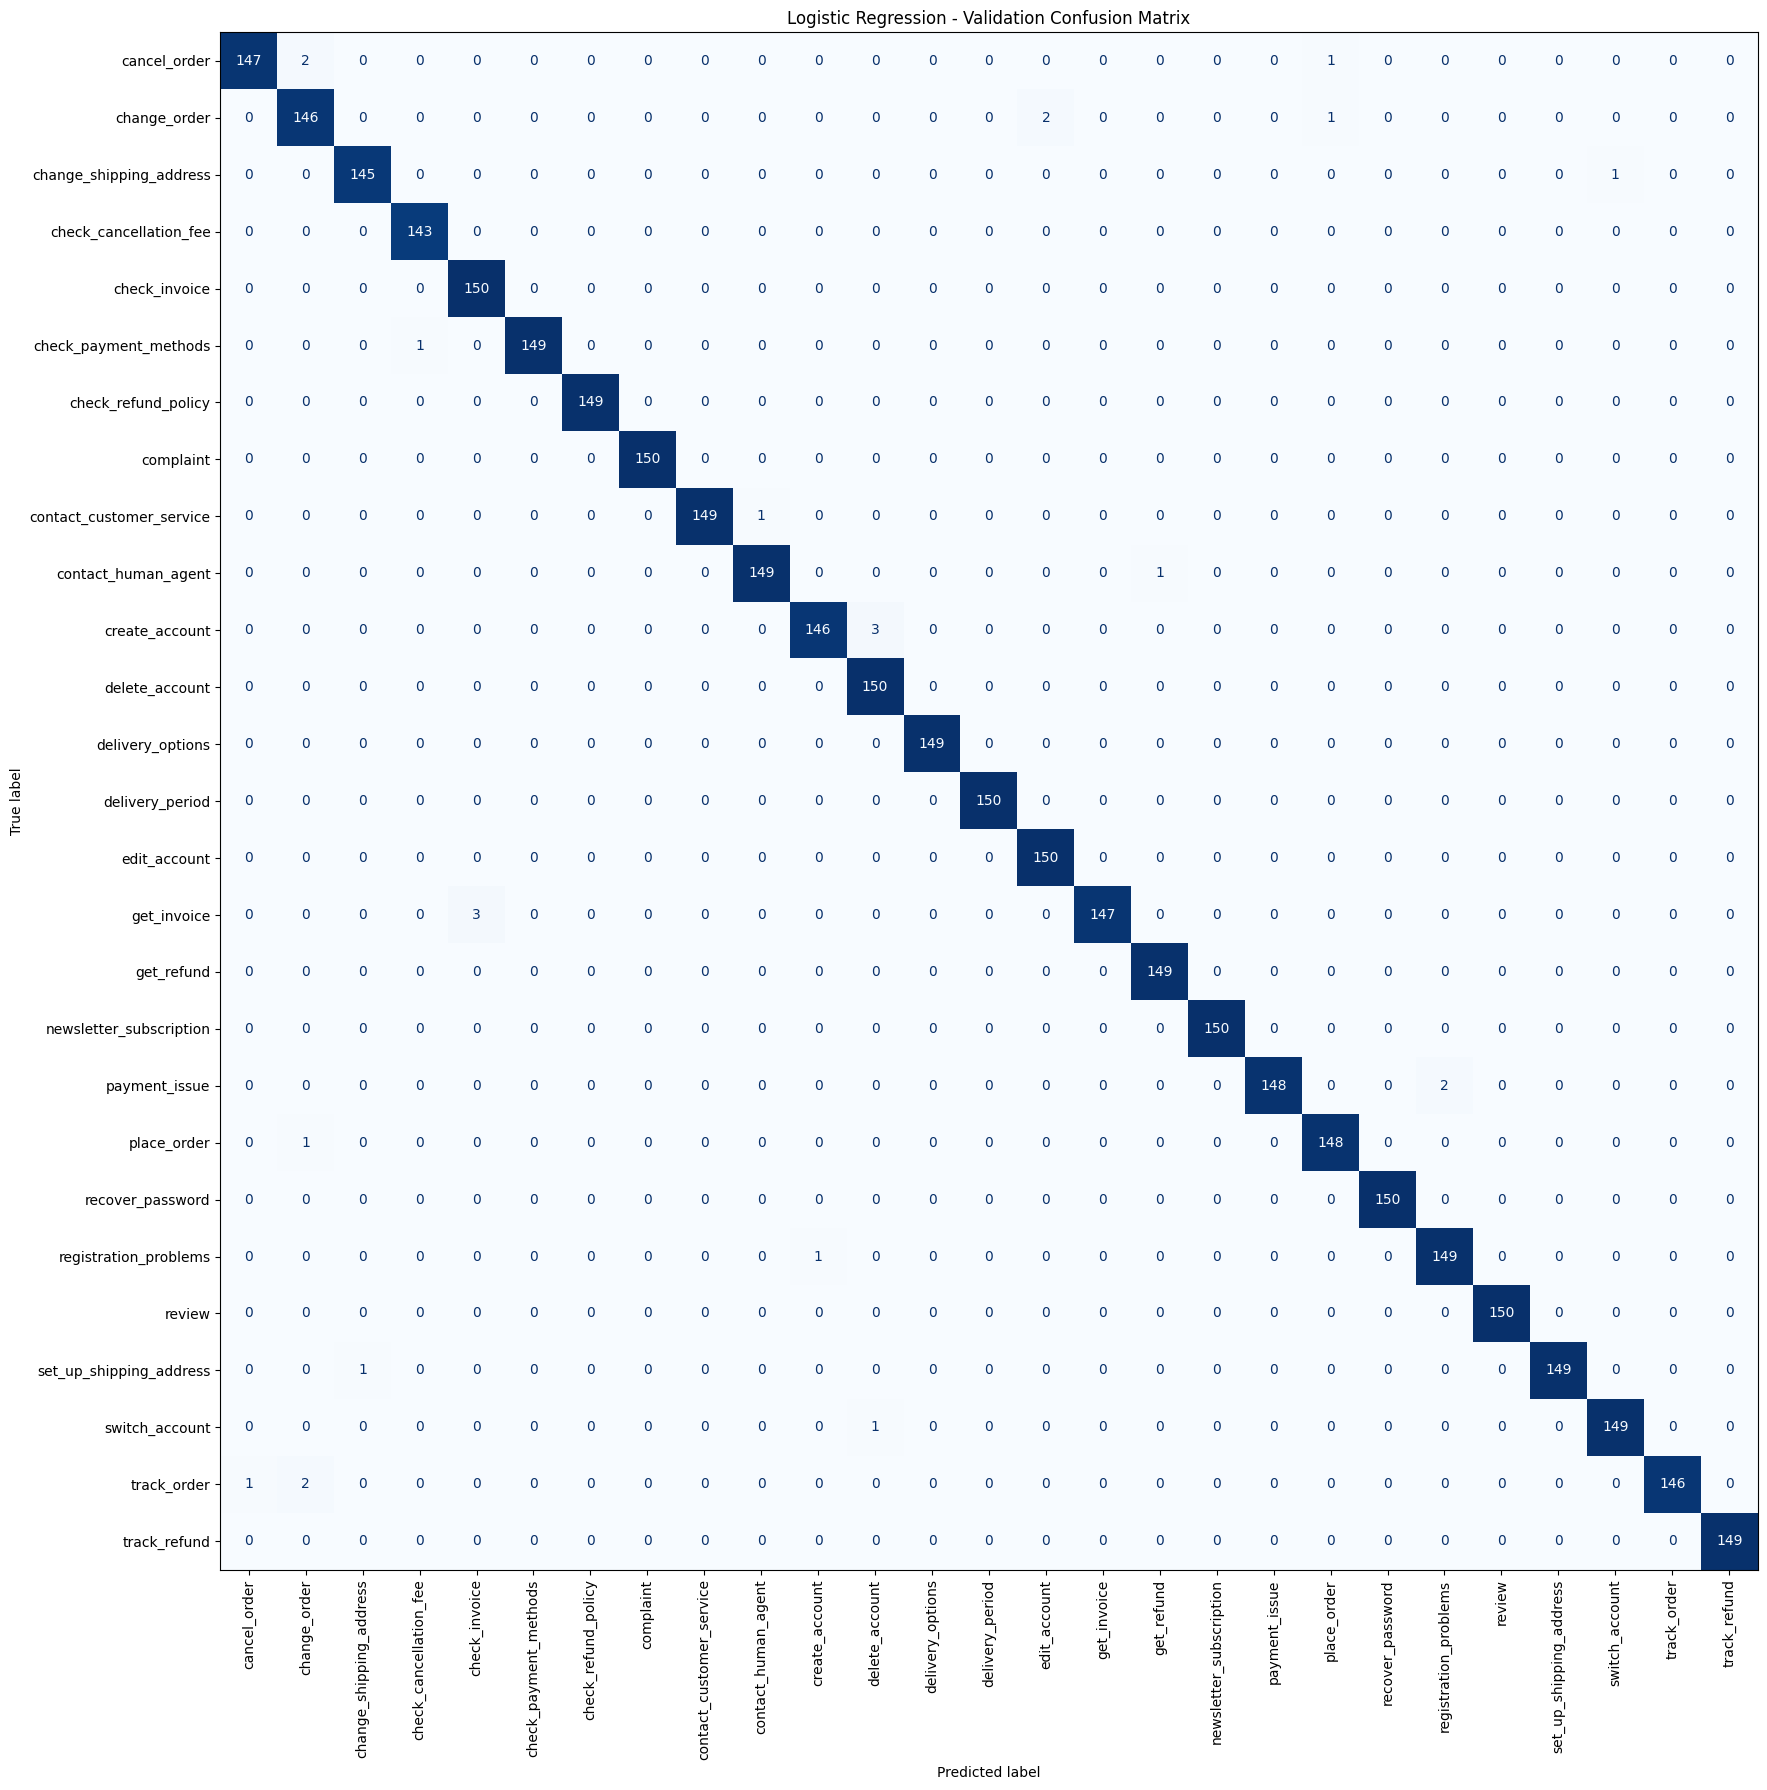

In [ ]:
# ============================================
# Logistic Regression - Confusion Matrix
# ============================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --------------------------------------------
# Plot Confusion Matrix
# --------------------------------------------

fig, ax = plt.subplots(figsize=(18, 18))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    val_predictions,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False,
    ax=ax
)

plt.title("Logistic Regression - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Restore Project Paths After Runtime Restart
# ============================================

from pathlib import Path

# Mount Google Drive (if not already mounted)
from google.colab import drive
drive.mount('/content/drive')

# Project Root
PROJECT_ROOT = Path("/content/drive/MyDrive/SupportPilotAI")

# Project Folders
RAW_DATA_DIR = PROJECT_ROOT / "datasets" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "datasets" / "processed"
MAPPINGS_DIR = PROJECT_ROOT / "datasets" / "mappings"

MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
REPORTS_DIR = PROJECT_ROOT / "reports"
KNOWLEDGE_BASE_DIR = PROJECT_ROOT / "knowledge_base"

print("Project paths restored successfully.")

Mounted at /content/drive
Project paths restored successfully.


In [ ]:
# ============================================
# Restore Session After Runtime Disconnect
# ============================================

import pandas as pd
import joblib

# --------------------------------------------
# Load Processed Datasets
# --------------------------------------------

intent_train_df = pd.read_csv(PROCESSED_DATA_DIR / "intent_train.csv")
intent_validation_df = pd.read_csv(PROCESSED_DATA_DIR / "intent_validation.csv")
intent_test_df = pd.read_csv(PROCESSED_DATA_DIR / "intent_test.csv")


# --------------------------------------------
# Load Saved TF-IDF Vectorizer
# --------------------------------------------

tfidf_vectorizer = joblib.load(
    MODELS_DIR / "tfidf_vectorizer.pkl"
)

# --------------------------------------------
# Transform Text into TF-IDF Features
# --------------------------------------------


X_train_tfidf = tfidf_vectorizer.transform(intent_train_df["instruction"])
X_val_tfidf = tfidf_vectorizer.transform(intent_validation_df["instruction"])
X_test_tfidf = tfidf_vectorizer.transform(intent_test_df["instruction"])

# --------------------------------------------
# Target Labels
# --------------------------------------------

y_train = intent_train_df["intent"]
y_val = intent_validation_df["intent"]
y_test = intent_test_df["intent"]

# --------------------------------------------
# Verify Restoration
# --------------------------------------------

print("=" * 80)
print("Session Restored Successfully")
print("=" * 80)

print(f"Train Shape      : {train_df.shape}")
print(f"Validation Shape : {validation_df.shape}")
print(f"Test Shape       : {test_df.shape}")

print(f"\nTF-IDF Train Matrix : {X_train_tfidf.shape}")
print(f"TF-IDF Val Matrix   : {X_val_tfidf.shape}")
print(f"TF-IDF Test Matrix  : {X_test_tfidf.shape}")

print(f"\nVocabulary Size : {len(tfidf_vectorizer.vocabulary_):,}")
print("Intent Train Shape :", X_train_tfidf.shape)
print("Intent Validation Shape :", X_val_tfidf.shape)
print("Intent Test Shape :", X_test_tfidf.shape)

print("\nVectorizer Vocabulary Size :", len(tfidf_vectorizer.vocabulary_))



Session Restored Successfully
Train Shape      : (140000, 2)
Validation Shape : (30000, 2)
Test Shape       : (30000, 2)

TF-IDF Train Matrix : (18810, 4930)
TF-IDF Val Matrix   : (4031, 4930)
TF-IDF Test Matrix  : (4031, 4930)

Vocabulary Size : 4,930
Intent Train Shape : (18810, 4930)
Intent Validation Shape : (4031, 4930)
Intent Test Shape : (4031, 4930)

Vectorizer Vocabulary Size : 4930


In [ ]:
# ============================================
# Calibrated Linear SVM - Intent Classification
# ============================================

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report

# --------------------------------------------
# Initialize Base Linear SVM
# --------------------------------------------

base_svm = LinearSVC(
    random_state=42,
    max_iter=5000
)

# --------------------------------------------
# Initialize Calibrated Classifier
# --------------------------------------------

intent_classifier = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",
    cv=5
)

# --------------------------------------------
# Train Model
# --------------------------------------------

intent_classifier.fit(
    X_train_tfidf,
    y_train
)

# --------------------------------------------
# Validation Prediction
# --------------------------------------------

svm_predictions = intent_classifier.predict(
    X_val_tfidf
)

# --------------------------------------------
# Evaluate Model
# --------------------------------------------

svm_accuracy = accuracy_score(
    y_val,
    svm_predictions
)

print("=" * 80)
print("Calibrated Linear SVM Validation Results")
print("=" * 80)

print(f"Validation Accuracy : {svm_accuracy:.4f}")

print("\nClassification Report")
print("-" * 80)

print(classification_report(
    y_val,
    svm_predictions
))

Calibrated Linear SVM Validation Results
Validation Accuracy : 0.9955

Classification Report
--------------------------------------------------------------------------------
                          precision    recall  f1-score   support

            cancel_order       0.99      0.99      0.99       150
            change_order       0.97      0.99      0.98       149
 change_shipping_address       0.99      1.00      0.99       146
  check_cancellation_fee       1.00      1.00      1.00       143
           check_invoice       0.99      0.99      0.99       150
   check_payment_methods       1.00      1.00      1.00       150
     check_refund_policy       1.00      1.00      1.00       149
               complaint       1.00      1.00      1.00       150
contact_customer_service       1.00      0.99      1.00       150
     contact_human_agent       0.99      0.99      0.99       150
          create_account       1.00      0.99      0.99       149
          delete_account       0.

In [ ]:
# ============================================
# Multinomial Naive Bayes - Intent Classification
# ============================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# --------------------------------------------
# Initialize Multinomial Naive Bayes
# --------------------------------------------

naive_bayes = MultinomialNB()

# --------------------------------------------
# Train Model
# --------------------------------------------

naive_bayes.fit(X_train_tfidf, y_train)

# --------------------------------------------
# Validation Prediction
# --------------------------------------------

nb_predictions = naive_bayes.predict(X_val_tfidf)

# --------------------------------------------
# Evaluate Model
# --------------------------------------------

nb_accuracy = accuracy_score(y_val, nb_predictions)

print("=" * 80)
print("Multinomial Naive Bayes Validation Results")
print("=" * 80)

print(f"Validation Accuracy : {nb_accuracy:.4f}")

print("\nClassification Report")
print("-" * 80)

print(classification_report(y_val, nb_predictions))

Multinomial Naive Bayes Validation Results
Validation Accuracy : 0.9888

Classification Report
--------------------------------------------------------------------------------
                          precision    recall  f1-score   support

            cancel_order       0.97      0.98      0.98       150
            change_order       0.99      0.97      0.98       149
 change_shipping_address       0.96      1.00      0.98       146
  check_cancellation_fee       1.00      1.00      1.00       143
           check_invoice       0.99      0.97      0.98       150
   check_payment_methods       1.00      1.00      1.00       150
     check_refund_policy       0.99      0.99      0.99       149
               complaint       0.99      1.00      1.00       150
contact_customer_service       1.00      0.99      1.00       150
     contact_human_agent       0.99      0.99      0.99       150
          create_account       1.00      0.99      0.99       149
          delete_account       

Calibrated Linear SVM Test Set Evaluation
Test Accuracy : 0.9953

Classification Report
--------------------------------------------------------------------------------
                          precision    recall  f1-score   support

            cancel_order       1.00      0.99      1.00       149
            change_order       0.98      0.98      0.98       150
 change_shipping_address       0.99      1.00      1.00       146
  check_cancellation_fee       1.00      1.00      1.00       142
           check_invoice       0.98      0.99      0.99       150
   check_payment_methods       1.00      1.00      1.00       150
     check_refund_policy       1.00      1.00      1.00       150
               complaint       1.00      1.00      1.00       150
contact_customer_service       1.00      0.99      1.00       150
     contact_human_agent       0.99      1.00      1.00       150
          create_account       0.99      0.97      0.98       150
          delete_account       0.99   

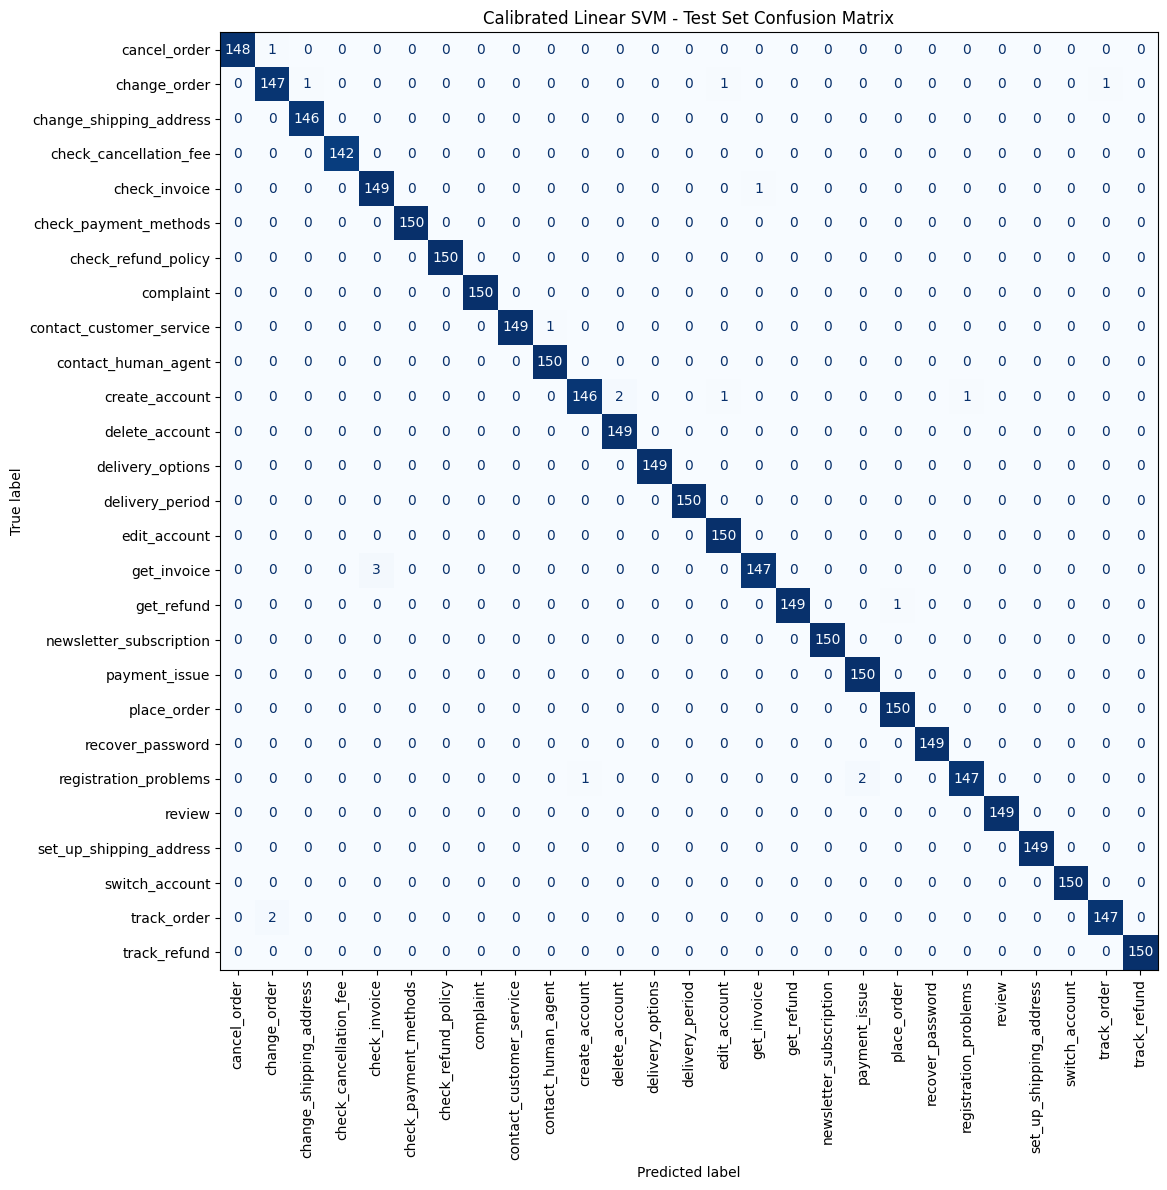

In [ ]:
# ============================================
# Final Evaluation on Test Set - Calibrated Linear SVM
# ============================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# --------------------------------------------
# Predict on Test Set
# --------------------------------------------

test_predictions = intent_classifier.predict(X_test_tfidf)

# --------------------------------------------
# Compute Accuracy
# --------------------------------------------

test_accuracy = accuracy_score(y_test, test_predictions)

print("=" * 80)
print("Calibrated Linear SVM Test Set Evaluation")
print("=" * 80)

print(f"Test Accuracy : {test_accuracy:.4f}")

print("\nClassification Report")
print("-" * 80)

print(classification_report(y_test, test_predictions))

# --------------------------------------------
# Confusion Matrix
# --------------------------------------------

cm = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=intent_classifier.classes_
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    colorbar=False
)

plt.title("Calibrated Linear SVM - Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Error Analysis - Misclassified Test Samples
# ============================================

import pandas as pd

# --------------------------------------------
# Create Error Analysis DataFrame
# --------------------------------------------

error_df = pd.DataFrame({
    "Customer_Query": intent_test_df["instruction"].values,
    "Actual_Intent": y_test.values,
    "Predicted_Intent": test_predictions
})

# --------------------------------------------
# Filter Incorrect Predictions
# --------------------------------------------

misclassified_df = error_df[
    error_df["Actual_Intent"] != error_df["Predicted_Intent"]
].reset_index(drop=True)

# --------------------------------------------
# Display Results
# --------------------------------------------

print("=" * 80)
print("Error Analysis")
print("=" * 80)

print(f"Total Test Samples      : {len(intent_test_df)}")
print(f"Correct Predictions     : {len(intent_test_df) - len(misclassified_df)}")
print(f"Incorrect Predictions   : {len(misclassified_df)}")

print("\nFirst 20 Misclassified Samples")
print("-" * 80)

display(misclassified_df.head(20))

Error Analysis
Total Test Samples      : 4031
Correct Predictions     : 4012
Incorrect Predictions   : 19

First 20 Misclassified Samples
--------------------------------------------------------------------------------


,Customer_Query,Actual_Intent,Predicted_Intent
0,"I have to modigy purchase <ORDER_NUMBER>, help me",change_order,track_order
1,creating user,create_account,registration_problems
2,update purchase00123842,change_order,edit_account
3,i have got to locte order <ORDER_NUMBER>,track_order,change_order
4,I do not know how I can inform of problems wit...,registration_problems,payment_issue
5,i do not know what to do to cdheck my bill #85632,check_invoice,get_invoice
6,I want assistance creatinga standard account,create_account,delete_account
7,is it possible to crewate a gold account,create_account,delete_account
8,what do i need to do to inform of an error wit...,registration_problems,payment_issue
9,I need help to requestreimbursements,get_refund,place_order


In [ ]:
# ============================================
# Save Best Intent Classification Model
# ============================================

import joblib

# --------------------------------------------
# Save Linear SVM Model
# --------------------------------------------

joblib.dump(
    intent_classifier,
    MODELS_DIR / "intent_classifier_linear_svm.pkl"
)

# --------------------------------------------
# Save TF-IDF Vectorizer
# --------------------------------------------

joblib.dump(
    tfidf_vectorizer,
    MODELS_DIR / "intent_tfidf_vectorizer.pkl"
)

print("=" * 80)
print("Intent Classification Model Saved Successfully")
print("=" * 80)

print(f"Model      : {MODELS_DIR / 'intent_classifier_linear_svm.pkl'}")
print(f"Vectorizer : {MODELS_DIR / 'intent_tfidf_vectorizer.pkl'}")
print(f"Validation Accuracy : {svm_accuracy:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

Intent Classification Model Saved Successfully
Model      : /content/drive/MyDrive/SupportPilotAI/models/intent_classifier_linear_svm.pkl
Vectorizer : /content/drive/MyDrive/SupportPilotAI/models/intent_tfidf_vectorizer.pkl
Validation Accuracy : 0.9955
Test Accuracy       : 0.9953


In [ ]:
# ============================================
# Load Processed Sentiment Dataset
# ============================================

import pandas as pd

sentiment_df = pd.read_csv(
    PROCESSED_DATA_DIR / "sentiment_clean.csv"
)

print("=" * 80)
print("Sentiment Dataset Loaded Successfully")
print("=" * 80)

print(f"Dataset Shape : {sentiment_df.shape}")

display(sentiment_df.head())

Sentiment Dataset Loaded Successfully
Dataset Shape : (1597185, 2)


,instruction,sentiment
0,- A that's a bummer. You shoulda got David Car...,0
1,is upset that he can't update his Facebook by ...,0
2,I dived many times for the ball. Managed to sa...,0
3,my whole body feels itchy and like its on fire,0
4,"no, it's not behaving at all. i'm mad. why am ...",0


In [ ]:
# ============================================
# Phase 9 - Sentiment Dataset Analysis
# ============================================

print("=" * 80)
print("Sentiment Dataset Information")
print("=" * 80)

print(f"Dataset Shape : {sentiment_df.shape}")

print("\nColumns")
print("-" * 80)
print(sentiment_df.columns.tolist())

print("\nMissing Values")
print("-" * 80)
print(sentiment_df.isnull().sum())

print("\nLabel Distribution")
print("-" * 80)
print(sentiment_df["sentiment"].value_counts().sort_index())

print("\nPercentage Distribution")
print("-" * 80)
print(
    (
        sentiment_df["sentiment"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)

Sentiment Dataset Information
Dataset Shape : (1597185, 2)

Columns
--------------------------------------------------------------------------------
['instruction', 'sentiment']

Missing Values
--------------------------------------------------------------------------------
instruction    1
sentiment      0
dtype: int64

Label Distribution
--------------------------------------------------------------------------------
sentiment
0    798497
4    798688
Name: count, dtype: int64

Percentage Distribution
--------------------------------------------------------------------------------
sentiment
0    49.99
4    50.01
Name: proportion, dtype: float64


In [ ]:
# ============================================
# Phase 9 - Create Balanced Stratified Subset
# ============================================

# --------------------------------------------
# Remove Missing Text
# --------------------------------------------

sentiment_df = sentiment_df.dropna(subset=["instruction"]).reset_index(drop=True)

# --------------------------------------------
# Create Balanced Subset
# --------------------------------------------

SAMPLES_PER_CLASS = 100_000

negative_df = sentiment_df[
    sentiment_df["sentiment"] == 0
].sample(
    n=SAMPLES_PER_CLASS,
    random_state=42
)

positive_df = sentiment_df[
    sentiment_df["sentiment"] == 4
].sample(
    n=SAMPLES_PER_CLASS,
    random_state=42
)

# --------------------------------------------
# Combine & Shuffle
# --------------------------------------------

sentiment_subset_df = (
    pd.concat([negative_df, positive_df])
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

# --------------------------------------------
# Display Summary
# --------------------------------------------

print("=" * 80)
print("Balanced Sentiment Subset Created")
print("=" * 80)

print(f"Subset Shape : {sentiment_subset_df.shape}")

print("\nClass Distribution")
print("-" * 80)

print(sentiment_subset_df["sentiment"].value_counts())

print("\nPercentage Distribution")
print("-" * 80)

print(
    (
        sentiment_subset_df["sentiment"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

Balanced Sentiment Subset Created
Subset Shape : (200000, 2)

Class Distribution
--------------------------------------------------------------------------------
sentiment
4    100000
0    100000
Name: count, dtype: int64

Percentage Distribution
--------------------------------------------------------------------------------
sentiment
4    50.0
0    50.0
Name: proportion, dtype: float64


In [ ]:
# ============================================
# Phase 9 - Train / Validation / Test Split
# ============================================

from sklearn.model_selection import train_test_split

# --------------------------------------------
# First Split (Train 70%, Temp 30%)
# --------------------------------------------

train_df, temp_df = train_test_split(
    sentiment_subset_df,
    test_size=0.30,
    stratify=sentiment_subset_df["sentiment"],
    random_state=42
)

# --------------------------------------------
# Second Split (Validation 15%, Test 15%)
# --------------------------------------------

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["sentiment"],
    random_state=42
)

# --------------------------------------------
# Display Split Summary
# --------------------------------------------

print("=" * 80)
print("Train / Validation / Test Split Completed")
print("=" * 80)

print(f"Training Samples    : {len(train_df):,}")
print(f"Validation Samples  : {len(validation_df):,}")
print(f"Test Samples        : {len(test_df):,}")

print("\nClass Distribution")

print("-" * 80)

print("Training")
print(train_df["sentiment"].value_counts().sort_index())

print("\nValidation")
print(validation_df["sentiment"].value_counts().sort_index())

print("\nTest")
print(test_df["sentiment"].value_counts().sort_index())

Train / Validation / Test Split Completed
Training Samples    : 140,000
Validation Samples  : 30,000
Test Samples        : 30,000

Class Distribution
--------------------------------------------------------------------------------
Training
sentiment
0    70000
4    70000
Name: count, dtype: int64

Validation
sentiment
0    15000
4    15000
Name: count, dtype: int64

Test
sentiment
0    15000
4    15000
Name: count, dtype: int64


In [ ]:
# ============================================
# Save Sentiment Train/Validation/Test Splits
# ============================================

train_df.to_csv(
    PROCESSED_DATA_DIR / "sentiment_train.csv",
    index=False
)

validation_df.to_csv(
    PROCESSED_DATA_DIR / "sentiment_validation.csv",
    index=False
)

test_df.to_csv(
    PROCESSED_DATA_DIR / "sentiment_test.csv",
    index=False
)

print("=" * 80)
print("Sentiment Dataset Splits Saved Successfully")
print("=" * 80)

print(f"Training     : {len(train_df):,}")
print(f"Validation   : {len(validation_df):,}")
print(f"Test         : {len(test_df):,}")

In [ ]:
# ============================================
# Save Sentiment Train/Validation/Test Splits
# ============================================

train_df.to_csv(
    PROCESSED_DATA_DIR / "sentiment_train.csv",
    index=False
)

validation_df.to_csv(
    PROCESSED_DATA_DIR / "sentiment_validation.csv",
    index=False
)

test_df.to_csv(
    PROCESSED_DATA_DIR / "sentiment_test.csv",
    index=False
)

print("=" * 80)
print("Sentiment Dataset Splits Saved Successfully")
print("=" * 80)

print(f"Training     : {len(train_df):,}")
print(f"Validation   : {len(validation_df):,}")
print(f"Test         : {len(test_df):,}")

Sentiment Dataset Splits Saved Successfully
Training     : 140,000
Validation   : 30,000
Test         : 30,000


In [ ]:
# ============================================
# Phase 9 - TF-IDF Feature Engineering
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer

# --------------------------------------------
# Separate Features and Labels
# --------------------------------------------

X_train = train_df["instruction"]
y_train = train_df["sentiment"]

X_validation = validation_df["instruction"]
y_validation = validation_df["sentiment"]

X_test = test_df["instruction"]
y_test = test_df["sentiment"]

# --------------------------------------------
# Initialize TF-IDF Vectorizer
# --------------------------------------------

sentiment_tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    stop_words=None,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# --------------------------------------------
# Fit on Training Data Only
# --------------------------------------------

X_train_tfidf = sentiment_tfidf_vectorizer.fit_transform(X_train)

# --------------------------------------------
# Transform Validation & Test Data
# --------------------------------------------

X_validation_tfidf = sentiment_tfidf_vectorizer.transform(X_validation)
X_test_tfidf = sentiment_tfidf_vectorizer.transform(X_test)

# --------------------------------------------
# Display Summary
# --------------------------------------------

print("=" * 80)
print("TF-IDF Feature Engineering Completed")
print("=" * 80)

print(f"Training Shape   : {X_train_tfidf.shape}")
print(f"Validation Shape : {X_validation_tfidf.shape}")
print(f"Test Shape       : {X_test_tfidf.shape}")

print(f"\nVocabulary Size : {len(sentiment_tfidf_vectorizer.vocabulary_):,}")

TF-IDF Feature Engineering Completed
Training Shape   : (140000, 157084)
Validation Shape : (30000, 157084)
Test Shape       : (30000, 157084)

Vocabulary Size : 157,084


In [ ]:
# ============================================
# Phase 9 - Logistic Regression
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --------------------------------------------
# Initialize Logistic Regression
# --------------------------------------------

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

# --------------------------------------------
# Train Model
# --------------------------------------------

logistic_model.fit(
    X_train_tfidf,
    y_train
)

# --------------------------------------------
# Validation Prediction
# --------------------------------------------

validation_predictions_lr = logistic_model.predict(
    X_validation_tfidf
)

# --------------------------------------------
# Validation Accuracy
# --------------------------------------------

lr_accuracy = accuracy_score(
    y_validation,
    validation_predictions_lr
)

print("=" * 80)
print("Logistic Regression Completed")
print("=" * 80)

print(f"Validation Accuracy : {lr_accuracy:.4f}")

Logistic Regression Completed
Validation Accuracy : 0.7935


In [ ]:
# ============================================
# Phase 9 - Linear SVM
# ============================================

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# --------------------------------------------
# Initialize Linear SVM
# --------------------------------------------

linear_svm_model = LinearSVC(
    random_state=42
)

# --------------------------------------------
# Train Model
# --------------------------------------------

linear_svm_model.fit(
    X_train_tfidf,
    y_train
)

# --------------------------------------------
# Validation Prediction
# --------------------------------------------

validation_predictions_svm = linear_svm_model.predict(
    X_validation_tfidf
)

# --------------------------------------------
# Validation Accuracy
# --------------------------------------------

svm_accuracy = accuracy_score(
    y_validation,
    validation_predictions_svm
)

print("=" * 80)
print("Linear SVM Completed")
print("=" * 80)

print(f"Validation Accuracy : {svm_accuracy:.4f}")

Linear SVM Completed
Validation Accuracy : 0.7813


In [ ]:
# ============================================
# Phase 9 - Multinomial Naive Bayes
# ============================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# --------------------------------------------
# Initialize Model
# --------------------------------------------

naive_bayes_model = MultinomialNB()

# --------------------------------------------
# Train Model
# --------------------------------------------

naive_bayes_model.fit(
    X_train_tfidf,
    y_train
)

# --------------------------------------------
# Validation Prediction
# --------------------------------------------

validation_predictions_nb = naive_bayes_model.predict(
    X_validation_tfidf
)

# --------------------------------------------
# Validation Accuracy
# --------------------------------------------

nb_accuracy = accuracy_score(
    y_validation,
    validation_predictions_nb
)

print("=" * 80)
print("Multinomial Naive Bayes Completed")
print("=" * 80)

print(f"Validation Accuracy : {nb_accuracy:.4f}")

Multinomial Naive Bayes Completed
Validation Accuracy : 0.7815


In [ ]:
# ============================================
# Phase 9 - Validation Evaluation (Best Model)
# ============================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("=" * 80)
print("Logistic Regression Validation Report")
print("=" * 80)

print(
    classification_report(
        y_validation,
        validation_predictions_lr,
        digits=4
    )
)

print("\nConfusion Matrix")
print("-" * 80)

cm = confusion_matrix(
    y_validation,
    validation_predictions_lr
)

print(cm)

Logistic Regression Validation Report
              precision    recall  f1-score   support

           0     0.7971    0.7873    0.7922     15000
           4     0.7899    0.7996    0.7947     15000

    accuracy                         0.7935     30000
   macro avg     0.7935    0.7935    0.7935     30000
weighted avg     0.7935    0.7935    0.7935     30000


Confusion Matrix
--------------------------------------------------------------------------------
[[11810  3190]
 [ 3006 11994]]


In [ ]:
# ============================================
# Phase 9 - Test Evaluation (Best Model)
# ============================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# --------------------------------------------
# Test Predictions
# --------------------------------------------

test_predictions_lr = logistic_model.predict(
    X_test_tfidf
)

# --------------------------------------------
# Test Accuracy
# --------------------------------------------

test_accuracy = accuracy_score(
    y_test,
    test_predictions_lr
)

print("=" * 80)
print("Logistic Regression Test Evaluation")
print("=" * 80)

print(f"Test Accuracy : {test_accuracy:.4f}")

print("\nClassification Report")
print("-" * 80)

print(
    classification_report(
        y_test,
        test_predictions_lr,
        digits=4
    )
)

print("\nConfusion Matrix")
print("-" * 80)

test_cm = confusion_matrix(
    y_test,
    test_predictions_lr
)

print(test_cm)

Logistic Regression Test Evaluation
Test Accuracy : 0.7963

Classification Report
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.7997    0.7906    0.7951     15000
           4     0.7929    0.8019    0.7974     15000

    accuracy                         0.7963     30000
   macro avg     0.7963    0.7963    0.7963     30000
weighted avg     0.7963    0.7963    0.7963     30000


Confusion Matrix
--------------------------------------------------------------------------------
[[11859  3141]
 [ 2971 12029]]


In [ ]:
# ============================================
# Save Best Sentiment Classification Model
# ============================================

import joblib

# --------------------------------------------
# Save Logistic Regression Model
# --------------------------------------------

joblib.dump(
    logistic_model,
    MODELS_DIR / "sentiment_classifier_logistic_regression.pkl"
)

# --------------------------------------------
# Save TF-IDF Vectorizer
# --------------------------------------------

joblib.dump(
    sentiment_tfidf_vectorizer,
    MODELS_DIR / "sentiment_tfidf_vectorizer.pkl"
)

print("=" * 80)
print("Sentiment Classification Model Saved Successfully")
print("=" * 80)

print(f"Model      : {MODELS_DIR / 'sentiment_classifier_logistic_regression.pkl'}")
print(f"Vectorizer : {MODELS_DIR / 'sentiment_tfidf_vectorizer.pkl'}")
print(f"Validation Accuracy : {lr_accuracy:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

Sentiment Classification Model Saved Successfully
Model      : /content/drive/MyDrive/SupportPilotAI/models/sentiment_classifier_logistic_regression.pkl
Vectorizer : /content/drive/MyDrive/SupportPilotAI/models/sentiment_tfidf_vectorizer.pkl
Validation Accuracy : 0.7935
Test Accuracy       : 0.7963


In [ ]:
# ============================================
# Phase 9 - Error Analysis
# ============================================

import pandas as pd

# --------------------------------------------
# Create Error Analysis DataFrame
# --------------------------------------------

error_analysis_df = pd.DataFrame({
    "Text": X_test.reset_index(drop=True),
    "Actual": y_test.reset_index(drop=True),
    "Predicted": test_predictions_lr
})

# --------------------------------------------
# Prediction Status
# --------------------------------------------

error_analysis_df["Correct"] = (
    error_analysis_df["Actual"] ==
    error_analysis_df["Predicted"]
)

# --------------------------------------------
# Summary
# --------------------------------------------

correct_predictions = error_analysis_df["Correct"].sum()
incorrect_predictions = len(error_analysis_df) - correct_predictions

print("=" * 80)
print("Error Analysis Summary")
print("=" * 80)

print(f"Total Test Samples     : {len(error_analysis_df):,}")
print(f"Correct Predictions    : {correct_predictions:,}")
print(f"Incorrect Predictions  : {incorrect_predictions:,}")

print("\nAccuracy Check")

print(
    f"{correct_predictions / len(error_analysis_df):.4f}"
)

Error Analysis Summary
Total Test Samples     : 30,000
Correct Predictions    : 23,888
Incorrect Predictions  : 6,112

Accuracy Check
0.7963


In [ ]:
# ============================================
# Phase 9 - View Misclassified Samples
# ============================================

# --------------------------------------------
# Extract Misclassified Samples
# --------------------------------------------

misclassified_df = error_analysis_df[
    error_analysis_df["Correct"] == False
].copy()

# --------------------------------------------
# Display Summary
# --------------------------------------------

print("=" * 80)
print("Misclassified Samples")
print("=" * 80)

print(f"Total Misclassified Samples : {len(misclassified_df):,}")

print("\nFirst 20 Misclassified Samples\n")

display(
    misclassified_df.head(20)
)

Misclassified Samples
Total Misclassified Samples : 6,112

First 20 Misclassified Samples



,Text,Actual,Predicted,Correct
0,its sooo warm tonight,0,4,False
1,I watched it too! But only half I love Taylor!,0,4,False
10,Tested a fix for the S60 route generator utili...,0,4,False
19,"- I hope you guys have fun tonight, we're bumm...",0,4,False
23,I miss training tho. Once I get my full time j...,4,0,False
30,actually no. I kept the old ones.,4,0,False
40,One thing I do remember from last night.. Me t...,4,0,False
51,Just picked up Barkley from the groomers...he ...,0,4,False
53,Nako! I was supposed to be last! You tricked m...,4,0,False
66,"Quite honestly, there is no issue here. Never ...",4,0,False


In [ ]:
# ============================================
# Phase 10 - Load Intent Dataset
# ============================================

import pandas as pd

# --------------------------------------------
# Load Processed Intent Dataset
# --------------------------------------------

intent_df = pd.read_csv(
    PROCESSED_DATA_DIR / "intent_clean.csv"
)

# --------------------------------------------
# Display All Intent Labels
# --------------------------------------------

all_intents = sorted(intent_df["intent"].unique())

print("=" * 80)
print("Available Intent Classes")
print("=" * 80)

for i, intent in enumerate(all_intents, start=1):
    print(f"{i:2d}. {intent}")

print("\nTotal Intent Classes :", len(all_intents))

Available Intent Classes
 1. cancel_order
 2. change_order
 3. change_shipping_address
 4. check_cancellation_fee
 5. check_invoice
 6. check_payment_methods
 7. check_refund_policy
 8. complaint
 9. contact_customer_service
10. contact_human_agent
11. create_account
12. delete_account
13. delivery_options
14. delivery_period
15. edit_account
16. get_invoice
17. get_refund
18. newsletter_subscription
19. payment_issue
20. place_order
21. recover_password
22. registration_problems
23. review
24. set_up_shipping_address
25. switch_account
26. track_order
27. track_refund

Total Intent Classes : 27


In [ ]:
# ============================================
# Phase 10 - Base Priority Mapping
# ============================================

# --------------------------------------------
# Base Priority Assigned to Each Intent
# --------------------------------------------

base_priority = {

    # -------------------------------
    # Critical
    # -------------------------------
    "payment_issue": "Critical",
    "complaint": "Critical",
    "delete_account": "Critical",

    # -------------------------------
    # High
    # -------------------------------
    "cancel_order": "High",
    "change_order": "High",
    "change_shipping_address": "High",
    "get_refund": "High",
    "track_refund": "High",
    "recover_password": "High",
    "registration_problems": "High",
    "contact_human_agent": "High",

    # -------------------------------
    # Medium
    # -------------------------------
    "check_cancellation_fee": "Medium",
    "check_invoice": "Medium",
    "check_payment_methods": "Medium",
    "check_refund_policy": "Medium",
    "contact_customer_service": "Medium",
    "delivery_options": "Medium",
    "delivery_period": "Medium",
    "edit_account": "Medium",
    "get_invoice": "Medium",
    "place_order": "Medium",
    "set_up_shipping_address": "Medium",
    "switch_account": "Medium",

    # -------------------------------
    # Low
    # -------------------------------
    "create_account": "Low",
    "newsletter_subscription": "Low",
    "review": "Low",
    "track_order": "Low"
}

print("=" * 80)
print("Base Priority Mapping Created")
print("=" * 80)

print(f"Total Intents Covered : {len(base_priority)}")
print(f"Dataset Intent Count  : {len(all_intents)}")

missing_intents = sorted(set(all_intents) - set(base_priority.keys()))

if len(missing_intents) == 0:
    print("\n✅ All intents are covered.")
else:
    print("\n❌ Missing Intents:")
    for intent in missing_intents:
        print("-", intent)

Base Priority Mapping Created
Total Intents Covered : 27
Dataset Intent Count  : 27

✅ All intents are covered.


In [ ]:
# ============================================
# Phase 10 - Priority Adjustment Engine
# ============================================

# --------------------------------------------
# Priority Order
# --------------------------------------------

priority_levels = [
    "Low",
    "Medium",
    "High",
    "Critical"
]


# --------------------------------------------
# Function to Adjust Priority
# --------------------------------------------

def adjust_priority(base_priority, sentiment):

    # Negative sentiment increases priority
    if sentiment == 0:

        current_index = priority_levels.index(base_priority)

        # Increase by one level if not already Critical
        if current_index < len(priority_levels) - 1:
            return priority_levels[current_index + 1]

    # Positive sentiment keeps the same priority
    return base_priority


# --------------------------------------------
# Test Examples
# --------------------------------------------

examples = [

    ("payment_issue", "Critical", 0),
    ("payment_issue", "Critical", 4),

    ("track_order", "Low", 0),
    ("track_order", "Low", 4),

    ("review", "Low", 0),
    ("review", "Low", 4),

    ("cancel_order", "High", 0),
    ("cancel_order", "High", 4),
]

print("=" * 90)
print("Priority Adjustment Examples")
print("=" * 90)

for intent, base, sentiment in examples:

    final_priority = adjust_priority(base, sentiment)

    sentiment_name = "Negative" if sentiment == 0 else "Positive"

    print(
        f"Intent: {intent:20} | "
        f"Sentiment: {sentiment_name:8} | "
        f"Base: {base:8} -> Final: {final_priority}"
    )

Priority Adjustment Examples
Intent: payment_issue        | Sentiment: Negative | Base: Critical -> Final: Critical
Intent: payment_issue        | Sentiment: Positive | Base: Critical -> Final: Critical
Intent: track_order          | Sentiment: Negative | Base: Low      -> Final: Medium
Intent: track_order          | Sentiment: Positive | Base: Low      -> Final: Low
Intent: review               | Sentiment: Negative | Base: Low      -> Final: Medium
Intent: review               | Sentiment: Positive | Base: Low      -> Final: Low
Intent: cancel_order         | Sentiment: Negative | Base: High     -> Final: Critical
Intent: cancel_order         | Sentiment: Positive | Base: High     -> Final: High


In [ ]:
# ============================================
# Phase 10 - Priority Decision Engine
# ============================================

# --------------------------------------------
# Function to Get Final Priority
# --------------------------------------------

def get_ticket_priority(intent, sentiment):
    """
    Returns the Base Priority and Final Priority
    using Intent and Sentiment.
    """

    # Check if intent exists
    if intent not in base_priority:
        raise ValueError(f"Unknown intent: {intent}")

    # Get base priority
    base = base_priority[intent]

    # Adjust priority using sentiment
    final = adjust_priority(base, sentiment)

    return {
        "Intent": intent,
        "Sentiment": "Negative" if sentiment == 0 else "Positive",
        "Base Priority": base,
        "Final Priority": final
    }


# --------------------------------------------
# Test Examples
# --------------------------------------------

test_cases = [

    ("payment_issue", 0),
    ("payment_issue", 4),

    ("track_order", 0),
    ("track_order", 4),

    ("review", 0),
    ("review", 4),

    ("recover_password", 0),
    ("recover_password", 4),

    ("complaint", 0),
    ("create_account", 4)

]

print("=" * 90)
print("Priority Decision Engine")
print("=" * 90)

for intent, sentiment in test_cases:

    result = get_ticket_priority(intent, sentiment)

    print(f"\nIntent         : {result['Intent']}")
    print(f"Sentiment      : {result['Sentiment']}")
    print(f"Base Priority  : {result['Base Priority']}")
    print(f"Final Priority : {result['Final Priority']}")

Priority Decision Engine

Intent         : payment_issue
Sentiment      : Negative
Base Priority  : Critical
Final Priority : Critical

Intent         : payment_issue
Sentiment      : Positive
Base Priority  : Critical
Final Priority : Critical

Intent         : track_order
Sentiment      : Negative
Base Priority  : Low
Final Priority : Medium

Intent         : track_order
Sentiment      : Positive
Base Priority  : Low
Final Priority : Low

Intent         : review
Sentiment      : Negative
Base Priority  : Low
Final Priority : Medium

Intent         : review
Sentiment      : Positive
Base Priority  : Low
Final Priority : Low

Intent         : recover_password
Sentiment      : Negative
Base Priority  : High
Final Priority : Critical

Intent         : recover_password
Sentiment      : Positive
Base Priority  : High
Final Priority : High

Intent         : complaint
Sentiment      : Negative
Base Priority  : Critical
Final Priority : Critical

Intent         : create_account
Sentiment     

In [ ]:
# ============================================
# Phase 10 - Load Trained Models
# ============================================

import joblib

# --------------------------------------------
# Load Intent Classification Artifacts
# --------------------------------------------

intent_vectorizer = joblib.load(
    MODELS_DIR / "intent_tfidf_vectorizer.pkl"
)

intent_classifier = joblib.load(
    MODELS_DIR / "intent_classifier_linear_svm.pkl"
)

# --------------------------------------------
# Load Sentiment Classification Artifacts
# --------------------------------------------

sentiment_vectorizer = joblib.load(
    MODELS_DIR / "sentiment_tfidf_vectorizer.pkl"
)

sentiment_classifier = joblib.load(
    MODELS_DIR / "sentiment_classifier_logistic_regression.pkl"
)

print("=" * 80)
print("Models Loaded Successfully")
print("=" * 80)

print("✓ Intent TF-IDF Vectorizer")
print("✓ Intent Classifier (Linear SVM)")
print("✓ Sentiment TF-IDF Vectorizer")
print("✓ Sentiment Classifier (Logistic Regression)")

Models Loaded Successfully
✓ Intent TF-IDF Vectorizer
✓ Intent Classifier (Linear SVM)
✓ Sentiment TF-IDF Vectorizer
✓ Sentiment Classifier (Logistic Regression)


In [ ]:
# ============================================
# Phase 10 - End-to-End Ticket Analysis
# ============================================

def analyze_customer_ticket(customer_query):
    """
    Analyze a customer query and return:
    1. Predicted Intent
    2. Predicted Sentiment
    3. Base Priority
    4. Final Priority
    """

    # --------------------------------------------
    # Intent Prediction
    # --------------------------------------------
    intent_features = intent_vectorizer.transform([customer_query])
    predicted_intent = intent_classifier.predict(intent_features)[0]

    # --------------------------------------------
    # Sentiment Prediction
    # --------------------------------------------
    sentiment_features = sentiment_vectorizer.transform([customer_query])
    predicted_sentiment = sentiment_classifier.predict(sentiment_features)[0]

    # --------------------------------------------
    # Priority Decision
    # --------------------------------------------
    priority_result = get_ticket_priority(
        predicted_intent,
        predicted_sentiment
    )

    # --------------------------------------------
    # Return Complete Analysis
    # --------------------------------------------
    return {
        "Customer Query": customer_query,
        "Predicted Intent": predicted_intent,
        "Predicted Sentiment": priority_result["Sentiment"],
        "Base Priority": priority_result["Base Priority"],
        "Final Priority": priority_result["Final Priority"]
    }


# ============================================
# Example Queries
# ============================================

sample_queries = [

    "My payment failed and money has been deducted.",

    "Where is my order?",

    "I forgot my password and can't login.",

    "Please cancel my order immediately.",

    "Thank you for your support."

]

print("=" * 100)
print("End-to-End Ticket Analysis")
print("=" * 100)

for query in sample_queries:

    result = analyze_customer_ticket(query)

    print("\n" + "-" * 100)
    print(f"Customer Query       : {result['Customer Query']}")
    print(f"Predicted Intent     : {result['Predicted Intent']}")
    print(f"Predicted Sentiment  : {result['Predicted Sentiment']}")
    print(f"Base Priority        : {result['Base Priority']}")
    print(f"Final Priority       : {result['Final Priority']}")

End-to-End Ticket Analysis

----------------------------------------------------------------------------------------------------
Customer Query       : My payment failed and money has been deducted.
Predicted Intent     : payment_issue
Predicted Sentiment  : Negative
Base Priority        : Critical
Final Priority       : Critical

----------------------------------------------------------------------------------------------------
Customer Query       : Where is my order?
Predicted Intent     : delivery_period
Predicted Sentiment  : Negative
Base Priority        : Medium
Final Priority       : High

----------------------------------------------------------------------------------------------------
Customer Query       : I forgot my password and can't login.
Predicted Intent     : recover_password
Predicted Sentiment  : Negative
Base Priority        : High
Final Priority       : Critical

---------------------------------------------------------------------------------------------------

In [ ]:
# ============================================
# Phase 10 - Confidence Score Prediction
# ============================================

import numpy as np


# --------------------------------------------
# Enhanced Ticket Analysis
# --------------------------------------------

def analyze_customer_ticket_with_confidence(customer_query):

    # ----------------------------------------
    # Intent Prediction
    # ----------------------------------------

    intent_features = intent_vectorizer.transform([customer_query])

    predicted_intent = intent_classifier.predict(intent_features)[0]

    intent_probabilities = intent_classifier.predict_proba(
    intent_features)[0]

    intent_confidence = np.max(intent_probabilities)


    # ----------------------------------------
    # Sentiment Prediction
    # ----------------------------------------

    sentiment_features = sentiment_vectorizer.transform([customer_query])

    predicted_sentiment = sentiment_classifier.predict(sentiment_features)[0]

    sentiment_probabilities = sentiment_classifier.predict_proba(
        sentiment_features
    )[0]

    sentiment_confidence = np.max(sentiment_probabilities)


    # ----------------------------------------
    # Priority
    # ----------------------------------------

    priority_result = get_ticket_priority(
        predicted_intent,
        predicted_sentiment
    )


    # ----------------------------------------
    # Return Results
    # ----------------------------------------

    return {

        "Customer Query": customer_query,

        "Predicted Intent": predicted_intent,

        "Intent Confidence": round(intent_confidence * 100, 2),

        "Predicted Sentiment": priority_result["Sentiment"],

        "Sentiment Confidence": round(sentiment_confidence * 100, 2),

        "Base Priority": priority_result["Base Priority"],

        "Final Priority": priority_result["Final Priority"]

    }


# ============================================
# Test Queries
# ============================================

sample_queries = [

    "My payment failed and money has been deducted.",

    "Where is my order?",

    "I forgot my password and can't login.",

    "Please cancel my order immediately.",

    "Thank you for your support."

]

print("=" * 110)
print("Ticket Analysis with Confidence Scores")
print("=" * 110)

for query in sample_queries:

    result = analyze_customer_ticket_with_confidence(query)

    print("\n" + "-" * 110)

    print(f"Customer Query         : {result['Customer Query']}")

    print(f"Predicted Intent       : {result['Predicted Intent']}")

    print(f"Intent Confidence      : {result['Intent Confidence']}%")

    print(f"Predicted Sentiment    : {result['Predicted Sentiment']}")

    print(f"Sentiment Confidence   : {result['Sentiment Confidence']}%")

    print(f"Base Priority          : {result['Base Priority']}")

    print(f"Final Priority         : {result['Final Priority']}")

Ticket Analysis with Confidence Scores

--------------------------------------------------------------------------------------------------------------
Customer Query         : My payment failed and money has been deducted.
Predicted Intent       : payment_issue
Intent Confidence      : 90.78%
Predicted Sentiment    : Negative
Sentiment Confidence   : 85.42%
Base Priority          : Critical
Final Priority         : Critical

--------------------------------------------------------------------------------------------------------------
Customer Query         : Where is my order?
Predicted Intent       : delivery_period
Intent Confidence      : 58.14%
Predicted Sentiment    : Negative
Sentiment Confidence   : 67.2%
Base Priority          : Medium
Final Priority         : High

--------------------------------------------------------------------------------------------------------------
Customer Query         : I forgot my password and can't login.
Predicted Intent       : recover_password